# Lab 1 · Part 3 — The traffic model as a small service
### EUROCONTROL AI Lab · Exercise 1, Part 3

A forecast is useful only if planners' tools can **ask for it**. Here we run the model trained in Part 1 as a small **web service**
on **your own computer** (`127.0.0.1` = "this computer": nothing leaves the PC; in Google Colab it runs on the Colab machine), and talk to it the way another system would.

```
 this notebook / web browser ── request: the day + the traffic of the previous days ──►  serve_traffic.py  ──►  traffic_core.py + artifacts/
                             ◄── answer: {"forecast_flights": 541.3, ...} ──
```

| | |
|---|---|
| ⏱ **Time** | about 45 minutes |
| 🎓 **Prerequisites** | Part 1 (its section 8.1 saves the model in the `artifacts` folder). A ready-trained copy is included, so this part also works on its own. |

**What you will learn**
1. What a prediction **service** is: the model is loaded once and then answers many requests.
2. How the service **checks** its inputs and refuses nonsense.
3. Why training and serving must prepare the inputs with **the same code**.

> **How to use this notebook**
> - Run the cells **one at a time, from top to bottom**: click a cell and press **Shift + Enter**.
> - Every line of code has a comment (the text after `#`) explaining what it does. You do not need to write any code.
> - After each plot there is a short **📖 Reading** that explains what the plot tells us.
> - If something breaks, restart and run everything again: *Kernel → Restart Kernel and Run All Cells* (JupyterLab) or *Runtime → Restart session and run all* (Colab).
> - This notebook is yours to keep: you can re-run it later and change the numbers to experiment.

> ☁️ **Running in Google Colab?** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dblue-tech/ai-lab/blob/main/lab1_airport_traffic/Lab1_part3_serve.ipynb)  
> Run the next cell **first**: it copies the lab files (data, code, trained models) from GitHub into Colab, so that the rest of the notebook works exactly as on a PC. Wait for *"Colab ready"* (about half a minute).  
> To keep your own copy with your results: *File → Save a copy in Drive*.  
> **On a lab PC** the next cell does nothing: just run it and continue.

In [1]:
# ---- Only for Google Colab: get the lab files. On a lab PC this cell does nothing. ----
import os                                          # os: folders and files
import sys                                         # sys: information about the running Python
import subprocess                                  # subprocess: runs other programs (git, pip)

IN_COLAB = "google.colab" in sys.modules           # True when this notebook runs in Google Colab
if IN_COLAB:                                       # in Colab only:
    if not os.path.exists("/content/ai-lab"):      # if the lab files are not here yet...
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/dblue-tech/ai-lab.git", "/content/ai-lab"], check=True)   # ...copy them from GitHub
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--disable-pip-version-check", "fastapi", "uvicorn"], check=True)   # libraries for the service, not pre-installed in Colab
    os.chdir("/content/ai-lab/lab1_airport_traffic")# work inside this notebook's folder, as on a PC
    print("Colab ready — working in", os.getcwd())  # confirm
else:                                              # on a lab PC:
    print("Running on this computer: nothing to do")   # the files are already here

Running on this computer: nothing to do


---
## 0 · Setup

In [2]:
import sys                                        # sys: gives the path of the Python program
import time                                       # time: waiting
import subprocess                                 # subprocess: starts another program (the service) in the background
from pathlib import Path                          # Path: file paths that work on every operating system
import numpy as np                                # numpy: calculations on arrays
import pandas as pd                               # pandas: tables of data
import matplotlib.pyplot as plt                   # matplotlib: plots
import requests                                   # requests: sends messages (HTTP requests) to the service

LAB_DIR = Path(".").resolve()                     # this lab's folder (where serve_traffic.py is)
PORT = 8000                                       # the "door number" the service listens on
URL = "http://127.0.0.1:" + str(PORT)             # the address of the service on this computer
IN_COLAB = "google.colab" in sys.modules          # True when running in Google Colab

# ---- Plot style used in the whole notebook (you can skip reading this part) ----
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]  # 8 colours readable by colour-blind people
plt.rcParams["figure.figsize"] = (11, 4)                    # default figure size: 11 x 4 inches
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)  # use our colours, in this order, for the lines
plt.rcParams["axes.grid"] = True                            # draw a grid behind every plot
plt.rcParams["grid.color"] = "#e6e5e0"                      # make the grid light grey
plt.rcParams["axes.spines.top"] = False                     # hide the top border of the plot
plt.rcParams["axes.spines.right"] = False                   # hide the right border of the plot
plt.rcParams["axes.titleweight"] = "bold"                   # bold titles
plt.rcParams["lines.linewidth"] = 2                         # slightly thicker lines
plt.rcParams["legend.frameon"] = False                      # no box around the legend

---
## 1 · Start the service
The next cell starts `serve_traffic.py` in the background and waits until it answers. *(You can open `serve_traffic.py` in JupyterLab: it is short and every line is commented.)*

In [3]:
def service_is_running():                          # True if the service answers
    try:                                           # try to contact it...
        return requests.get(URL + "/health", timeout=1).ok   # ...on its /health address
    except requests.ConnectionError:               # nobody answers...
        return False                               # ...so it is not running


server = None                                      # no service started by this notebook yet
if not service_is_running():                       # if the service is not already running...
    command = [sys.executable, "-m", "uvicorn", "serve_traffic:app", "--host", "127.0.0.1", "--port", str(PORT)]   # the command
    server = subprocess.Popen(command, cwd=LAB_DIR, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)   # start it
    for attempt in range(60):                      # wait up to 30 seconds...
        if service_is_running():                   # ...until it answers
            break                                  # it answers: stop waiting
        if server.poll() is not None:              # if it stopped by itself...
            print(server.stdout.read())            # ...show its error (often: Part 1 was not run)
            break                                  # stop waiting
        time.sleep(0.5)                            # wait half a second and try again
print("Service running:", service_is_running())    # final check

Service running: True


The service documents itself — what to send and what it answers. Run the next cell and open the link in a new browser tab (on a lab PC the address is [http://127.0.0.1:8000/docs](http://127.0.0.1:8000/docs)).

In [4]:
if IN_COLAB:                                       # in Colab the service runs on Google's machine, not on your PC...
    from google.colab import output                # ...so Colab gives us a special link to reach it
    output.serve_kernel_port_as_window(PORT, path="/docs", anchor_text="Service documentation")   # show the link
else:                                              # on a lab PC:
    print("Service documentation:", URL + "/docs") # the address on this computer

Service documentation: http://127.0.0.1:8000/docs


---
## 2 · Ask the service

In [5]:
health = requests.get(URL + "/health").json()     # is it alive?
print(health)                                     # show the answer
LOOKBACK = health["lookback"]                     # how many past days the service needs

card = requests.get(URL + "/model").json()        # the model card saved in Part 1
print("Model:", card["name"])                     # its name
print("Predicts:", card["task"])                  # what it predicts
print("Test error:", card["test_mae"], "flights per day (baseline:", card["baseline_test_mae"], ")")   # how good it is

{'status': 'ok', 'model_version': '1.0.0', 'lookback': 7}
Model: Next-day IFR traffic forecast EBBR
Predicts: Total IFR movements (FLT_TOT_1) of the next day
Test error: 19.4 flights per day (baseline: 25.9 )


We ask for a forecast of **Monday 1 December 2025**, sending the real traffic of the days before (taken from the data file):

In [6]:
sys.path.insert(0, str(LAB_DIR))                  # let Python find traffic_core.py
import traffic_core                               # the shared code
series = traffic_core.load_series(LAB_DIR.parent / "data", card["airport"])   # the daily traffic 2023–2025

DAY = pd.Timestamp("2025-12-01")                  # the day to forecast
past_days = series[series.index < DAY].tail(LOOKBACK)   # the LOOKBACK days just before it
past_traffic = []                                 # their traffic, as plain numbers
for value in past_days.values:                    # for each past day...
    past_traffic.append(float(value))             # ...add its traffic

request_body = {"day": "2025-12-01", "past_traffic": past_traffic}   # the request: the day + the past traffic
print("We send:", request_body)                   # show what we send
answer = requests.post(URL + "/forecast", json=request_body)   # send it to the /forecast address
print("HTTP status:", answer.status_code)         # 200 = OK
print("Answer:", answer.json())                   # the service's answer
print("Real traffic that day:", int(series[DAY])) # what really happened

We send: {'day': '2025-12-01', 'past_traffic': [540.0, 472.0, 262.0, 566.0, 530.0, 433.0, 481.0]}
HTTP status: 200
Answer: {'day': '2025-12-01', 'forecast_flights': 477.2, 'baseline_same_weekday_last_week': 540.0, 'model_version': '1.0.0'}
Real traffic that day: 532


📖 **Reading:** the service answers with the model's forecast and, for comparison, the simple baseline *"same weekday last week"*. Any planning tool could now use it.
Notice that here the forecast is **below** reality: the past week contains the strike of 26 November (only 262 flights) — the over-reaction we saw in Part 2.

**What-if through the service:** the same past week, but asking for each day of that week — the answer changes only through the day of the week.

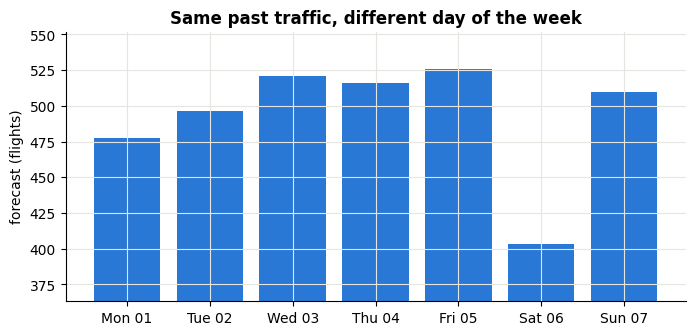

In [7]:
days = pd.date_range("2025-12-01", periods=7)     # Monday 1 … Sunday 7 December 2025
forecasts = []                                    # the answers
for d in days:                                    # for each day...
    body = {"day": d.strftime("%Y-%m-%d"), "past_traffic": past_traffic}   # ...same past traffic, different day
    forecasts.append(requests.post(URL + "/forecast", json=body).json()["forecast_flights"])   # ...ask the service

short_names = []                                  # short weekday names for the bars
for d in days:                                    # for each day...
    short_names.append(d.strftime("%a %d"))       # ...e.g. "Mon 01"
plt.figure(figsize=(8, 3.5))                      # new figure
plt.bar(short_names, forecasts, color=PALETTE[0]) # one bar per day
plt.ylim(min(forecasts) * 0.9, max(forecasts) * 1.05)   # zoom on the differences
plt.ylabel("forecast (flights)")                  # axis label
plt.title("Same past traffic, different day of the week")   # title
plt.show()                                        # display

---
## 3 · The service protects the model
We send some wrong requests on purpose.

In [8]:
too_short = {"day": "2025-12-01", "past_traffic": past_traffic[:3]}   # only 3 past days instead of LOOKBACK
answer = requests.post(URL + "/forecast", json=too_short)              # send it
print("Too few past days:", answer.status_code, answer.json()["detail"][0]["msg"])   # refused, with the reason

negative = {"day": "2025-12-01", "past_traffic": [-5.0] + past_traffic[1:]}   # a negative number of flights
answer = requests.post(URL + "/forecast", json=negative)                     # send it
print("Negative traffic:", answer.status_code, answer.json()["detail"][0]["msg"])   # refused

bad_date = {"day": "2025-13-45", "past_traffic": past_traffic}        # a date that does not exist
answer = requests.post(URL + "/forecast", json=bad_date)              # send it
print("Impossible date:", answer.status_code, answer.json()["detail"][0]["msg"])   # refused

reversed_order = {"day": "2025-12-01", "past_traffic": past_traffic[::-1]}   # the right numbers, but NEWEST first by mistake
answer = requests.post(URL + "/forecast", json=reversed_order)               # send it
print("Past days in the wrong order:", answer.status_code, answer.json())    # accepted!

Too few past days: 422 Value error, exactly 7 past days are needed, oldest first
Negative traffic: 422 Value error, each daily traffic value must be between 0 and 5000 flights
Impossible date: 422 Input should be a valid date or datetime, month value is outside expected range of 1-12
Past days in the wrong order: 200 {'day': '2025-12-01', 'forecast_flights': 500.4, 'baseline_same_weekday_last_week': 481.0, 'model_version': '1.0.0'}


📖 **Reading:** HTTP **422** = *"your data breaks the rules"*: impossible requests never reach the model.
But the last one — the right numbers in the **wrong order** — is accepted, and the forecast changes. The service cannot know that the client made a mistake.
**Checks catch impossible values, not plausible mistakes**: the order of the inputs is part of the *contract* between the service and its clients, and must be documented.

---
## 4 · Does the service give the same forecasts as the notebook?
We send every day of the test period (July–December 2025) to the service and compare with the forecasts computed directly from the saved model.

184 forecasts compared — largest difference: 0.05 flights


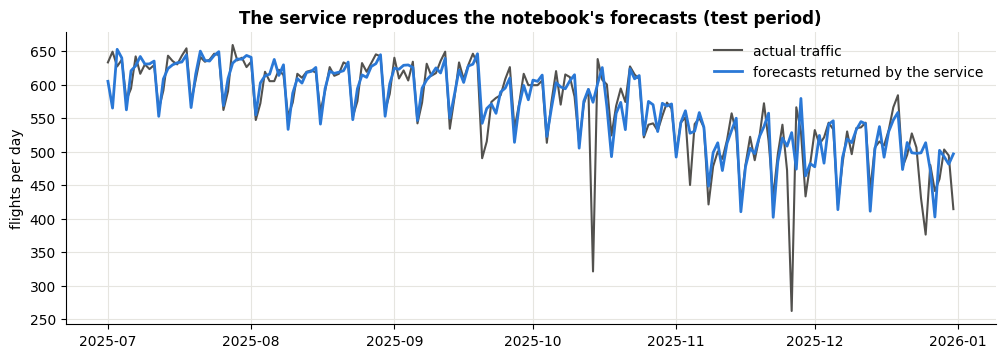

In [9]:
saved = traffic_core.SavedTrafficModel(LAB_DIR / "artifacts")   # the saved model, used directly
X_raw, y_true, dates = traffic_core.make_examples(series, LOOKBACK)   # all the examples
is_test = dates >= "2025-07-01"                   # the test period
direct = saved.forecast_many(X_raw[is_test])      # forecasts computed directly

service_forecasts = []                            # forecasts returned by the service
for x, d in zip(X_raw[is_test], dates[is_test]):  # for each test day (its inputs and its date)...
    past = []                                     # ...the past traffic as plain numbers
    for value in x[:LOOKBACK]:                    # for each past day...
        past.append(float(value))                 # ...its traffic
    body = {"day": d.strftime("%Y-%m-%d"), "past_traffic": past}   # ...the request
    service_forecasts.append(requests.post(URL + "/forecast", json=body).json()["forecast_flights"])   # ...the answer

difference = np.abs(np.array(service_forecasts) - direct).max()   # the largest difference
print(len(service_forecasts), "forecasts compared — largest difference:", round(float(difference), 3), "flights")   # only rounding

plt.figure(figsize=(12, 3.8))                     # new figure
plt.plot(dates[is_test], y_true[is_test], color="#52514e", linewidth=1.5, label="actual traffic")   # reality
plt.plot(dates[is_test], service_forecasts, color=PALETTE[0], label="forecasts returned by the service")   # service
plt.ylabel("flights per day")                     # axis label
plt.title("The service reproduces the notebook's forecasts (test period)")   # title
plt.legend()                                      # legend
plt.show()                                        # display

📖 **Reading:** the differences are only rounding (the service rounds to 0.1 flight): the service and the notebooks prepare the inputs with **the same file**, `traffic_core.py`.

---
## 5 · The web form
A simple page that sends the day and the past traffic to the same `/forecast` address. Run the next cell and open the link (on a lab PC: [http://127.0.0.1:8000/](http://127.0.0.1:8000/)). Change a number and see the forecast move.

In [10]:
if IN_COLAB:                                       # in Colab the service runs on Google's machine, not on your PC...
    from google.colab import output                # ...so Colab gives us a special link to reach it
    output.serve_kernel_port_as_window(PORT, path="/", anchor_text="Web form")   # show the link
else:                                              # on a lab PC:
    print("Web form:", URL + "/")                  # the address on this computer

Web form: http://127.0.0.1:8000/


---
## 6 · Stop the service

In [11]:
if server is not None:                             # if this notebook started the service...
    server.terminate()                             # ...ask it to stop...
    server.wait(timeout=10)                        # ...and wait until it has stopped
    print("Service stopped")                       # confirm
else:                                              # otherwise it was started somewhere else...
    print("Stop the service where you started it (Ctrl+C in its terminal)")   # ...stop it there

Service stopped


---
## 7 · Questions for discussion
1. The service accepted the past days in the wrong order. How could a client and a service avoid this kind of mistake?
2. To forecast tomorrow, the service needs today's final traffic count. When would that number be available in operations?
3. If this service were used every day by planners, what would you monitor to know that it is still working well?